In [63]:
from statsbombpy import sb
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
import pandas as pd
from mplsoccer import Pitch, Sbopen

In [64]:
match_id = 3802696
events = sb.events(match_id)
teamname = 'Paris Saint-Germain'

In [65]:
# Get the event index of the first sub for the team
first_sub = events[(events['type'] == 'Substitution') & (events['team'] == teamname)]["index"].min()
# Successful passes by the team before the first sub
passes = events[(events['type'] == 'Pass') & (events['team'] == teamname) & (events['index'] < first_sub) & (events['pass_outcome'].isna())]
# Take necessary columns
passes[['x', 'y']] = passes['location'].apply(pd.Series)[[0, 1]]
passes[['end_x', 'end_y']] = passes['pass_end_location'].apply(pd.Series)[[0, 1]]
passes = passes[['x', 'y', 'end_x', 'end_y', 'player', 'pass_recipient']].rename(
    columns={'player': 'player_name', 'pass_recipient': 'pass_recipient_name'}
).copy()
print(passes)

         x     y  end_x  end_y          player_name   pass_recipient_name
7     58.1  39.2   43.7   29.4   Idrissa Gana Gueye          Thilo Kehrer
8     43.9  29.6   54.3   39.6         Thilo Kehrer    Idrissa Gana Gueye
9     54.5  39.6   48.7   54.6   Idrissa Gana Gueye    Marcos Aoás Corrêa
10    51.9  61.8   48.9   30.1   Marcos Aoás Corrêa          Thilo Kehrer
11    47.9  22.0   65.1    8.7         Thilo Kehrer          Abdou Diallo
..     ...   ...    ...    ...                  ...                   ...
828    4.0  38.2    9.7   71.1  Keylor Navas Gamboa    Achraf Hakimi Mouh
830   27.4  74.0   24.1   67.0  Georginio Wijnaldum        Marco Verratti
831   27.8  70.1   33.8   55.7       Marco Verratti    Idrissa Gana Gueye
832   33.8  55.7   78.0   68.9   Idrissa Gana Gueye    Achraf Hakimi Mouh
833  103.5  58.4  110.0   35.0   Achraf Hakimi Mouh  Kylian Mbappé Lottin

[489 rows x 6 columns]


/tmp/ipykernel_1523825/2519445027.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  passes[['x', 'y']] = passes['location'].apply(pd.Series)[[0, 1]]
/tmp/ipykernel_1523825/2519445027.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  passes[['x', 'y']] = passes['location'].apply(pd.Series)[[0, 1]]
/tmp/ipykernel_1523825/2519445027.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in th

In [71]:
scatter_df = pd.DataFrame()
for i, name in enumerate(passes['player_name'].unique()):
    passx = passes[passes['player_name'] == name]['x'].to_numpy()
    passy = passes[passes['player_name'] == name]['y'].to_numpy()
    receivex = passes[passes['pass_recipient_name'] == name]['end_x'].to_numpy()
    receivey = passes[passes['pass_recipient_name'] == name]['end_y'].to_numpy()
    scatter_df.at[i, 'player_name'] = name
    scatter_df.at[i, "x"] = np.mean(np.concatenate([passx, receivex]))
    scatter_df.at[i, "y"] = np.mean(np.concatenate([passy, receivey]))
    scatter_df.at[i, "num_passes"] = len(passx)
# marker size to be proportional to number of passes
scatter_df['marker_size'] = scatter_df['num_passes'] / scatter_df['num_passes'].max() * 300
# Player nickname
lineups = sb.lineups(match_id)[teamname].set_index('player_name')
scatter_df['nickname'] = scatter_df['player_name'].map(lineups['player_nickname'])
scatter_df['nickname'].fillna(scatter_df['player_name'], inplace=True)
# Player nickname for display
def player_name_split(player_name):
    if isinstance(player_name, str):
        name_parts = player_name.split()
        if len(name_parts) == 1:
            return "", name_parts[0]
        elif len(name_parts) == 2:
            return name_parts[0], name_parts[1]
        else:
            return name_parts[0], " ".join(name_parts[1:])
    else:
        return "Unknown", "Unknown"
scatter_df[['first_name', 'last_name']] = scatter_df['nickname'].apply(lambda x: pd.Series(player_name_split(x)))
print(scatter_df)

                        player_name          x          y  num_passes  \
0                Idrissa Gana Gueye  61.809259  46.475000        57.0   
1                      Thilo Kehrer  40.794393  26.482243        56.0   
2                Marcos Aoás Corrêa  44.195699  52.881720        46.0   
3                      Abdou Diallo  54.098969  11.145361        51.0   
4     Neymar da Silva Santos Junior  76.878652  37.353933        40.0   
5                    Marco Verratti  59.222069  33.135862        76.0   
6               Georginio Wijnaldum  65.632911  60.397468        37.0   
7                Achraf Hakimi Mouh  73.786813  70.569231        46.0   
8               Keylor Navas Gamboa   7.307407  39.248148        18.0   
9   Ángel Fabián Di María Hernández  77.349383  44.424691        36.0   
10             Kylian Mbappé Lottin  85.649180  38.916393        26.0   

    marker_size             nickname first_name   last_name  
0    225.000000        Idrissa Gueye    Idrissa       Gueye  

/tmp/ipykernel_1523825/1301766630.py:16: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  scatter_df['nickname'].fillna(scatter_df['player_name'], inplace=True)


In [72]:
# Calculating passing arrow edge width based on number of passes between player pairs
passes["pair_key"] = passes.apply(lambda x: "_".join(sorted([x["player_name"], x["pass_recipient_name"]])), axis=1)
lines_df = passes.groupby(["pair_key"]).size().reset_index(name="pass_count")
# Setting a thereshold ignoring pairs with less than 2 passes
lines_df = lines_df[lines_df['pass_count'] > 2]
print(lines_df)

                                             pair_key  pass_count
1                     Abdou Diallo_Idrissa Gana Gueye           8
2                    Abdou Diallo_Keylor Navas Gamboa           5
3                   Abdou Diallo_Kylian Mbappé Lottin           6
4                         Abdou Diallo_Marco Verratti          19
5                     Abdou Diallo_Marcos Aoás Corrêa           6
6          Abdou Diallo_Neymar da Silva Santos Junior          14
7                           Abdou Diallo_Thilo Kehrer          32
8        Abdou Diallo_Ángel Fabián Di María Hernández           6
9              Achraf Hakimi Mouh_Georginio Wijnaldum          23
10              Achraf Hakimi Mouh_Idrissa Gana Gueye           9
12            Achraf Hakimi Mouh_Kylian Mbappé Lottin           8
13                  Achraf Hakimi Mouh_Marco Verratti           9
14              Achraf Hakimi Mouh_Marcos Aoás Corrêa          14
15   Achraf Hakimi Mouh_Neymar da Silva Santos Junior          10
16  Achraf

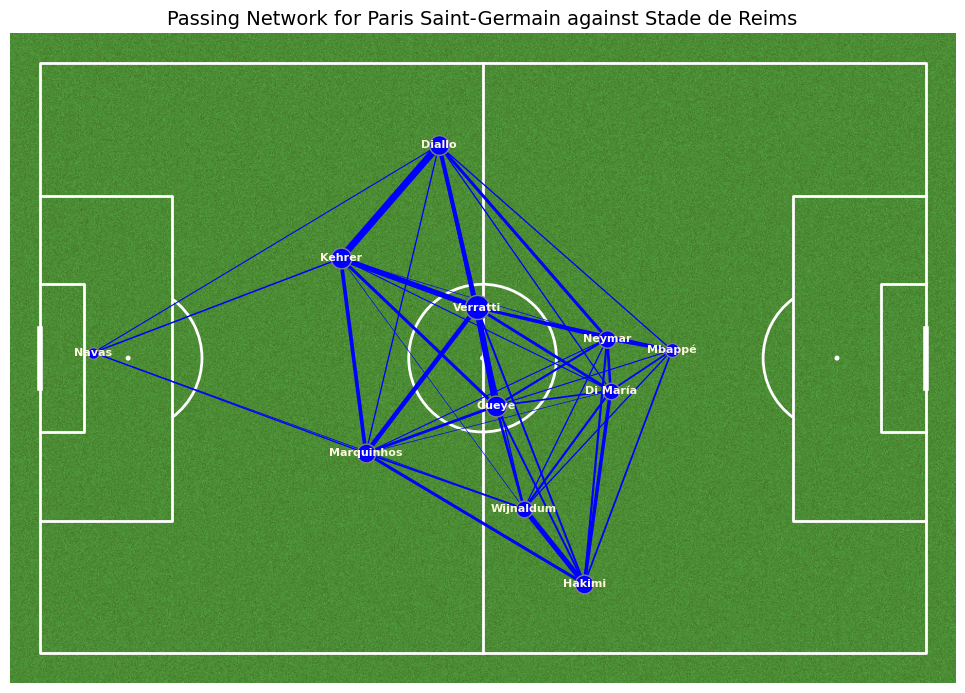

In [75]:
# Draw pitch and passing network
pitch = Pitch(pitch_type='statsbomb', pitch_color='grass', line_color='white')
fig, ax = pitch.draw(figsize=(10, 7))
# Draw player locations
for _, row in scatter_df.iterrows():
    pitch.scatter(row['x'], row['y'], s=row['marker_size'], color='blue', edgecolors='gray', linewidth=1, ax=ax, zorder=3)
    ax.text(row['x'], row['y'], row['last_name'], fontsize=8, fontweight='bold', ha='center', va='center', color='cornsilk', zorder=4)
# Draw passing arrows
for _, row in lines_df.iterrows():
    player1, player2 = row['pair_key'].split('_')
    player1_data = scatter_df[scatter_df['player_name'] == player1].iloc[0]
    player2_data = scatter_df[scatter_df['player_name'] == player2].iloc[0]
    pitch.lines(player1_data['x'], player1_data['y'], player2_data['x'], player2_data['y'], 
                lw=row['pass_count'] / lines_df['pass_count'].max() * 5, color='blue', ax=ax, zorder=2)
opponent_name = events[events['team'] != teamname]['team'].iloc[0]
plt.title(f'Passing Network for {teamname} against {opponent_name}', fontsize=14)
plt.show()

In [77]:
# Centralisation index
#calculate number of successful passes by player
no_passes = passes.groupby(['player_name']).x.count().reset_index()
no_passes.rename({'x':'pass_count'}, axis='columns', inplace=True)
#find one who made most passes
max_no = no_passes["pass_count"].max()
#calculate the denominator - 10*the total sum of passes
denominator = 10*no_passes["pass_count"].sum()
#calculate the nominator
nominator = (max_no - no_passes["pass_count"]).sum()
#calculate the centralisation index
centralisation_index = nominator/denominator
print("Centralisation index is ", centralisation_index)

Centralisation index is  0.07096114519427403
